In [5]:
import pandas as pd
import gzip
from pathlib import Path
 
# 1. Define paths
data_dir = Path("../../data/snvs/filtered_denominator_v2")
master_list_path = data_dir / "master_list.csv"

# 2. Load metadata
df_meta = pd.read_csv(master_list_path)

# Ensure LEGACY and UKCTOCS are grouped as 'PBMCs' (if they aren't already in the CSV)
# This looks for sample IDs starting with either name and forces the sample_type
mask_pbmc = df_meta['sample_id'].str.startswith('UKCTOCS') | df_meta['sample_id'].str.startswith('LEGACY')
df_meta.loc[mask_pbmc, 'sample_type'] = 'PBMCs'

# Helper function to parse VCF and extract INFO fields
# Helper function to parse VCF and extract INFO fields
def parse_vcf_variants(vcf_file):
    variants = []
    with gzip.open(vcf_file, 'rt') as f:
        for line in f:
            if line.startswith('#'):
                continue
            
            parts = line.strip().split('\t')
            if len(parts) < 8:
                continue
            
            chrom = parts[0]
            pos = int(parts[1])
            ref = parts[3]
            alts = parts[4].split(',') # Take the first ALT if there are multiple
            alt = alts[0]
            
            # Only keep Single Nucleotide Variants
            if len(ref) != 1 or len(alt) != 1:
                continue
                
            info_field = parts[7]
            n_alt, n_total = None, None
            for item in info_field.split(';'):
                if item.startswith('N_ALT='):
                    n_alt = float(item.split('=')[1])
                elif item.startswith('N_TOTAL='):
                    n_total = float(item.split('=')[1])
            
            if n_alt is not None and n_total is not None and n_total > 0:
                variants.append({
                    'CHROM': chrom,
                    'POS': pos,
                    'REF': ref,
                    'ALT': alt,
                    'VAF': n_alt / n_total,
                    'N_ALT': n_alt,       # <--- ADDED THIS
                    'N_TOTAL': n_total    # <--- ADDED THIS
                })
                
    return pd.DataFrame(variants)

# 3. Process all samples
all_variants_list = []
burden_summary_list = []

print("Loading VCFs and calculating burden...")

for _, row in df_meta.iterrows():
    sample_id = row['sample_id']
    
    # Dynamically find the VCF file in the ../Data directory based on sample_id
    search_pattern = f"{sample_id}_annotated.filtered.vcf.gz"
    found_files = list(data_dir.rglob(search_pattern))
    
    if not found_files:
        print(f"  [Warning] VCF not found for {sample_id}. Skipping.")
        continue
        
    vcf_path = found_files[0] # Take the first match
    
    # Parse the variants for this sample
    df_sample_vars = parse_vcf_variants(vcf_path)
    mutation_count = len(df_sample_vars)
    
    # --- Create a summary for Burden Plotting ---
    burden_summary_list.append({
        'sample_id': sample_id,
        'sample_type': row['sample_type'],
        'age': row['age'],
        'bases': row['total_callable_bases_in_wes'],
        'effective_territory': row['effective_territory'],
        'mutation_count': mutation_count,
        # Normalizing mutation count per Megabase (using sequenced bases or territory)
        'mutations_per_mb_sequenced': mutation_count / (row['total_callable_bases_in_wes'] / 1e6) if row['total_callable_bases_in_wes'] > 0 else 0
    })
    
    # --- Create a detailed DataFrame of ALL variants (useful later for signatures) ---
    if not df_sample_vars.empty:
        df_sample_vars['sample_id'] = sample_id
        df_sample_vars['sample_type'] = row['sample_type']
        df_sample_vars['age'] = row['age']
        df_sample_vars['bases'] = row['total_callable_bases_in_wes']
        all_variants_list.append(df_sample_vars)

# 4. Finalize DataFrames
df_burden = pd.DataFrame(burden_summary_list)
df_variants = pd.concat(all_variants_list, ignore_index=True)

print(f"Successfully loaded {len(df_burden)} samples.")
display(df_burden.head())

Loading VCFs and calculating burden...
Successfully loaded 36 samples.


,sample_id,sample_type,age,bases,effective_territory,mutation_count,mutations_per_mb_sequenced
0,27YO_UDI5,T_cells,27,1978103441,33817126,182,0.092007
1,27YO_UDI6,T_cells,27,2462100281,33817126,260,0.105601
2,UDI23_3x,T_cells,83,15138282907,33817126,3450,0.227899
3,UDI24_3x,T_cells,83,10554092498,33817126,2714,0.257151
4,UKCTOCS_UDI1,PBMCs,63,7626413040,33817126,910,0.119322


Discarding 27YO_UDI5: only 50.5% variants >= 50x
Discarding 27YO_UDI6: only 77.3% variants >= 50x
Discarding Cordblood_H1: only 68.5% variants >= 50x
Discarding Cordblood_H3: only 95.0% variants >= 50x
Discarding Cordblood_H5: only 92.9% variants >= 50x
Discarding Cordblood_H6: only 89.6% variants >= 50x
Discarding Cordblood_H7: only 81.8% variants >= 50x
Discarding Cordblood_H8: only 67.0% variants >= 50x
Discarding UKCTOCS_UDI5: only 93.5% variants >= 50x
Discarding UKCTOCS_UDI6: only 94.5% variants >= 50x
Discarding UKCTOCS_UDI8: only 90.5% variants >= 50x
Downsampling variants...


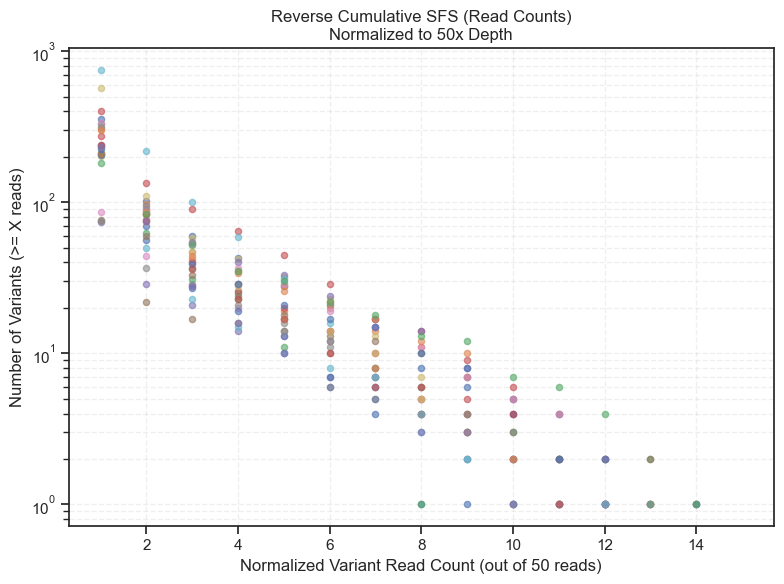

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="ticks")

# --- Parameters ---
TARGET_DEPTH = 50
DEPTH_PASS_RATIO = 0.95

# 1. Filter samples based on variant depth (Proxy for global depth)
samples_to_keep = []
for sample_id, group in df_variants.groupby('sample_id'):
    pct_above_target = (group['N_TOTAL'] >= TARGET_DEPTH).mean()
    if pct_above_target >= DEPTH_PASS_RATIO:
        samples_to_keep.append(sample_id)
    else:
        print(f"Discarding {sample_id}: only {pct_above_target:.1%} variants >= {TARGET_DEPTH}x")

df_filtered = df_variants[df_variants['sample_id'].isin(samples_to_keep)].copy()

# 2. Binomial downsampling for comparable SFS
print("Downsampling variants...")
# Draw new variant reads from a Binomial(TARGET_DEPTH, original_VAF)

# Hard filter to remove germline/high-VAF artifacts
df_filtered = df_filtered[df_filtered['VAF'] <= 0.20].copy()

# THEN run the binomial downsampling...
df_filtered['N_ALT_norm'] = np.random.binomial(n=TARGET_DEPTH, p=df_filtered['VAF'])
df_filtered['N_TOTAL_norm'] = TARGET_DEPTH
df_filtered['VAF_norm'] = df_filtered['N_ALT_norm'] / TARGET_DEPTH

# Remove variants that downsampled to 0 reads (lost variants)
df_norm = df_filtered[df_filtered['N_ALT_norm'] > 0].copy()

# 3. Plot Reverse Cumulative SFS based on Read Count
read_count_thresholds = np.arange(1, int(df_norm['N_ALT_norm'].max()) + 2)

plt.figure(figsize=(8, 6))

for sample_id, group in df_norm.groupby('sample_id'):
    # Count how many variants have N_ALT_norm >= t
    rev_cum_counts = [ (group['N_ALT_norm'] >= t).sum() for t in read_count_thresholds ]
    
    # Plot as discrete scatter
    plt.scatter(read_count_thresholds, rev_cum_counts, alpha=0.6, label=sample_id, s=20)

plt.yscale('log')
plt.xlabel(f"Normalized Variant Read Count (out of {TARGET_DEPTH} reads)")
plt.ylabel("Number of Variants (>= X reads)")
plt.title(f"Reverse Cumulative SFS (Read Counts)\nNormalized to {TARGET_DEPTH}x Depth")
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Uncomment if few samples
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.tight_layout()
plt.show()

Loading Mitchell single-cell data...
Applying WES BED filter to single-cell data (hg19)...
  BED filter: 1,403,557 → 16,741 variants (1.2% retained)
Downsampling variants...


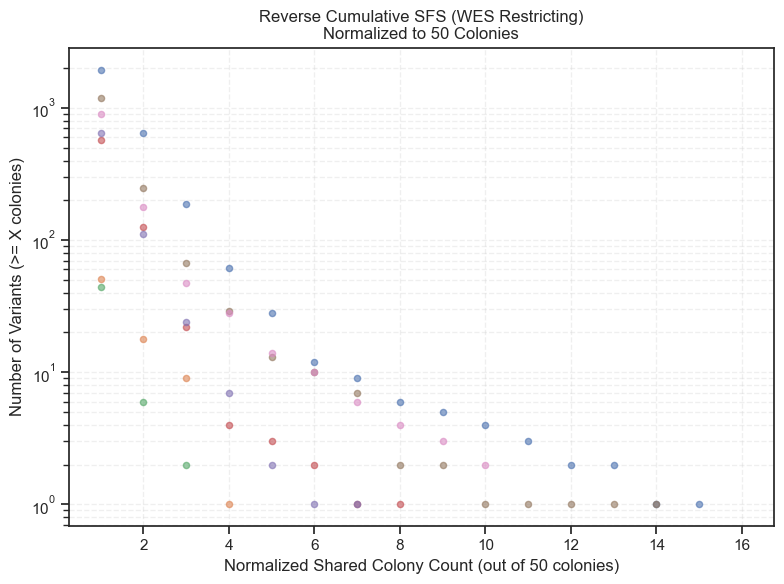

In [7]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="ticks")

# ─────────────────────────────────────────────────────────────────
# 0. Helper — BED intersection (From your earlier code)
# ─────────────────────────────────────────────────────────────────
def filter_variants_by_bed(df_variants, bed_path):
    """
    Keeps only variants whose POS (1-based) falls inside a BED interval
    (0-based half-open [start, end)).
    """
    bed = pd.read_csv(
        bed_path, sep='\t', header=None, comment='#',
        usecols=[0, 1, 2], names=['CHROM', 'START', 'END'],
        dtype={'CHROM': str, 'START': int, 'END': int}
    )

    df = df_variants.copy()
    bed['_chrom'] = bed['CHROM'].str.lstrip('chr')
    df['_chrom']  = df['CHROM'].astype(str).str.lstrip('chr')

    keep = pd.Series(False, index=df.index)

    for chrom, cb in bed.groupby('_chrom'):
        cb_sorted = cb.sort_values('START')
        starts = cb_sorted['START'].values   # 0-based inclusive
        ends   = cb_sorted['END'].values     # 0-based exclusive

        mask = df['_chrom'] == chrom
        if not mask.any():
            continue

        pos0 = df.loc[mask, 'POS'].values - 1   # convert to 0-based

        # Last interval whose start <= pos0
        idx = np.searchsorted(starts, pos0, side='right') - 1

        in_bed = np.zeros(len(pos0), dtype=bool)
        valid  = idx >= 0
        in_bed[valid] = pos0[valid] < ends[idx[valid]]

        keep.loc[df[mask].index] = in_bed

    n_before = len(df_variants)
    n_after  = int(keep.sum())
    print(f"  BED filter: {n_before:,} → {n_after:,} variants "
          f"({n_after/n_before*100:.1f}% retained)")

    return df.drop(columns=['_chrom'])[keep]


# ─────────────────────────────────────────────────────────────────
# 1. Load and Parse Single-Cell Data
# ─────────────────────────────────────────────────────────────────
print("Loading Mitchell single-cell data...")
df_sc = pd.read_csv("../../data/mitchell_SFS/mitchell_cellular_fractions.csv")

# Split the 'mutation_id' to extract CHROM and POS
# format is '1-100007740-C-T' -> [CHROM, POS, REF, ALT]
df_sc[['CHROM', 'POS', 'REF', 'ALT']] = df_sc['mutation_id'].str.split('-', expand=True)

# Ensure POS is an integer for the BED filter
df_sc['POS'] = df_sc['POS'].astype(int)

# ─────────────────────────────────────────────────────────────────
# 2. Filter by BED (Restrict to Exome)
# ─────────────────────────────────────────────────────────────────
bed_hg19_path = Path("../../resources/hg19_exome_panel.bed")
print("Applying WES BED filter to single-cell data (hg19)...")
df_sc_wes = filter_variants_by_bed(df_sc, bed_hg19_path)

# ─────────────────────────────────────────────────────────────────
# 3. Downsampling & SFS Parameters
# ─────────────────────────────────────────────────────────────────
TARGET_COLONIES = 50
COLONY_PASS_RATIO = 0.95

# Filter samples based on total colonies sequenced
samples_to_keep = []
for patient_id, group in df_sc_wes.groupby('patient_id'):
    pct_above_target = (group['total_colonies'] >= TARGET_COLONIES).mean()
    if pct_above_target >= COLONY_PASS_RATIO:
        samples_to_keep.append(patient_id)
    else:
        print(f"Discarding {patient_id}: only {pct_above_target:.1%} variants >= {TARGET_COLONIES} colonies")

df_filtered = df_sc_wes[df_sc_wes['patient_id'].isin(samples_to_keep)].copy()

# ─────────────────────────────────────────────────────────────────
# 4. Binomial downsampling for comparable SFS
# ─────────────────────────────────────────────────────────────────
print("Downsampling variants...")

# Hard filter to remove early embryonic/massive clones
# Bulk VAF 0.20 equates to a Cellular Fraction of 0.40
df_filtered = df_filtered[df_filtered['cellular_fraction'] <= 0.40].copy()

# Draw new variant colony counts from a Binomial(TARGET_COLONIES, original_cellular_fraction)
df_filtered['shared_norm'] = np.random.binomial(n=TARGET_COLONIES, p=df_filtered['cellular_fraction'])
df_filtered['total_norm'] = TARGET_COLONIES
df_filtered['cf_norm'] = df_filtered['shared_norm'] / TARGET_COLONIES

# Remove variants that downsampled to 0 colonies (lost variants)
df_norm = df_filtered[df_filtered['shared_norm'] > 0].copy()

# ─────────────────────────────────────────────────────────────────
# 5. Plot Reverse Cumulative SFS
# ─────────────────────────────────────────────────────────────────
colony_count_thresholds = np.arange(1, int(df_norm['shared_norm'].max()) + 2)

plt.figure(figsize=(8, 6))

for patient_id, group in df_norm.groupby('patient_id'):
    # Count how many variants have shared_norm >= t
    rev_cum_counts = [ (group['shared_norm'] >= t).sum() for t in colony_count_thresholds ]
    
    # Plot as discrete scatter
    plt.scatter(colony_count_thresholds, rev_cum_counts, alpha=0.6, label=patient_id, s=20)

plt.yscale('log')
plt.xlabel(f"Normalized Shared Colony Count (out of {TARGET_COLONIES} colonies)")
plt.ylabel("Number of Variants (>= X colonies)")
plt.title(f"Reverse Cumulative SFS (WES Restricting)\nNormalized to {TARGET_COLONIES} Colonies")
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# 1. Map ages to the Mitchell Single-Cell data
# (Update this dictionary with the actual metadata ages)
mitchell_ages = {
    "AX001": 63, 
    "KX001": 29, 
    "KX002": 38,
    "KX008": 76,
    "KX004": 77,
    "CB001": 0.75,
    "CB002": 0.75
    # Add remaining Mitchell IDs here...
}

# Assuming df_norm is your downsampled single-cell data from the previous step
df_sc_norm = df_norm.copy()
df_sc_norm['age'] = df_sc_norm['patient_id'].map(mitchell_ages)

# Drop any that you didn't have ages for yet so it doesn't break the plots
df_sc_norm = df_sc_norm.dropna(subset=['age']).copy()

# 2. Prepare and Downsample the Bulk Data
# (We need to downsample your bulk data just like we did for the single-cell data)
TARGET_DEPTH = 50

print("Preparing Bulk Data...")
# Filter to <= 20% VAF to remove early embryonic/germline artifacts
df_bulk_filtered = df_variants[df_variants['VAF'] <= 0.20].copy()

# Binomial Downsampling to standard depth
df_bulk_filtered['N_ALT_norm'] = np.random.binomial(n=TARGET_DEPTH, p=df_bulk_filtered['VAF'])
df_bulk_norm = df_bulk_filtered[df_bulk_filtered['N_ALT_norm'] > 0].copy()

print(f"Ready: {len(df_bulk_norm['sample_id'].unique())} Bulk samples, {len(df_sc_norm['patient_id'].unique())} Single-Cell samples.")

Preparing Bulk Data...
Ready: 36 Bulk samples, 7 Single-Cell samples.


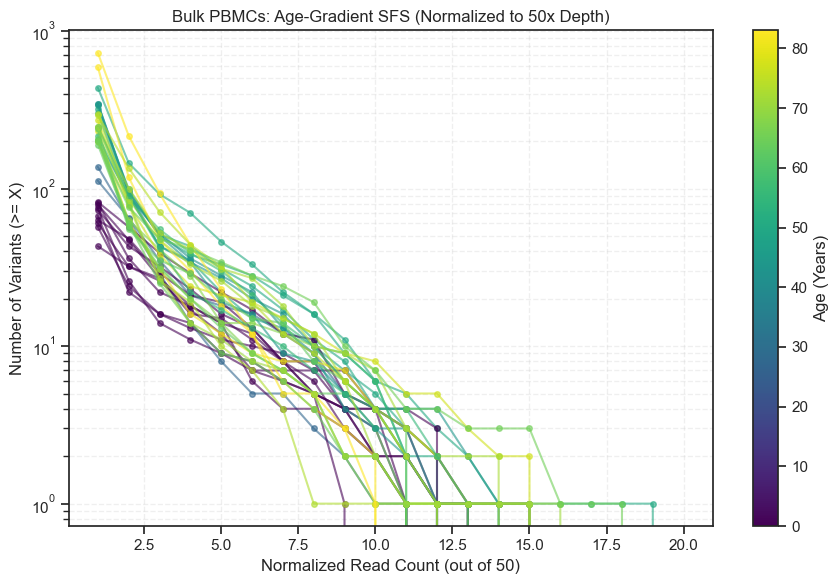

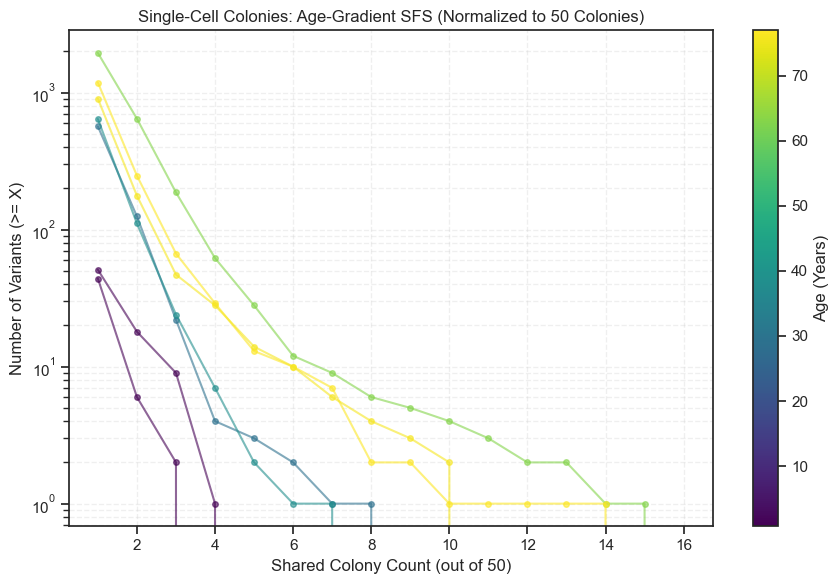

In [9]:
def plot_age_gradient_sfs(df, sample_col, value_col, max_val, title, xlabel):
    plt.figure(figsize=(9, 6))
    
    # Set up colormap based on age
    norm_color = mcolors.Normalize(vmin=df['age'].min(), vmax=df['age'].max())
    cmap = cm.viridis
    
    thresholds = np.arange(1, int(max_val) + 2)
    
    for sample_id, group in df.groupby(sample_col):
        age = group['age'].iloc[0]
        color = cmap(norm_color(age))
        
        # Calculate reverse cumulative count
        rev_cum_counts = [ (group[value_col] >= t).sum() for t in thresholds ]
        
        # Plot line
        plt.plot(thresholds, rev_cum_counts, color=color, alpha=0.6, marker='o', markersize=4)

    plt.yscale('log')
    plt.xlabel(xlabel)
    plt.ylabel("Number of Variants (>= X)")
    plt.title(title)
    plt.grid(True, which="both", ls="--", alpha=0.3)
    
    # Add a colorbar
    sm = cm.ScalarMappable(cmap=cmap, norm=norm_color)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=plt.gca())
    cbar.set_label('Age (Years)')
    
    plt.tight_layout()
    plt.show()

# Plot Bulk Data
plot_age_gradient_sfs(
    df=df_bulk_norm, 
    sample_col='sample_id', 
    value_col='N_ALT_norm', 
    max_val=df_bulk_norm['N_ALT_norm'].max(),
    title=f"Bulk PBMCs: Age-Gradient SFS (Normalized to {TARGET_DEPTH}x Depth)",
    xlabel=f"Normalized Read Count (out of {TARGET_DEPTH})"
)

# Plot Single-Cell Data
plot_age_gradient_sfs(
    df=df_sc_norm, 
    sample_col='patient_id', 
    value_col='shared_norm', 
    max_val=df_sc_norm['shared_norm'].max(),
    title=f"Single-Cell Colonies: Age-Gradient SFS (Normalized to {TARGET_COLONIES} Colonies)",
    xlabel=f"Shared Colony Count (out of {TARGET_COLONIES})"
)

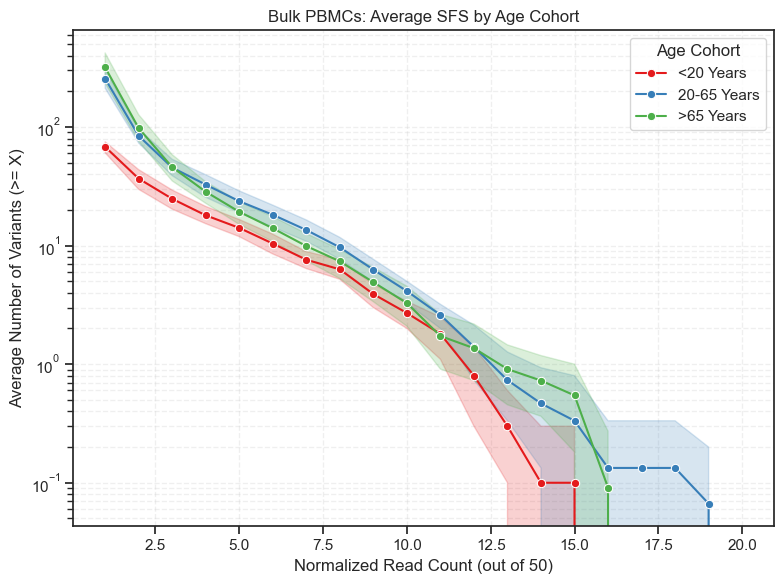

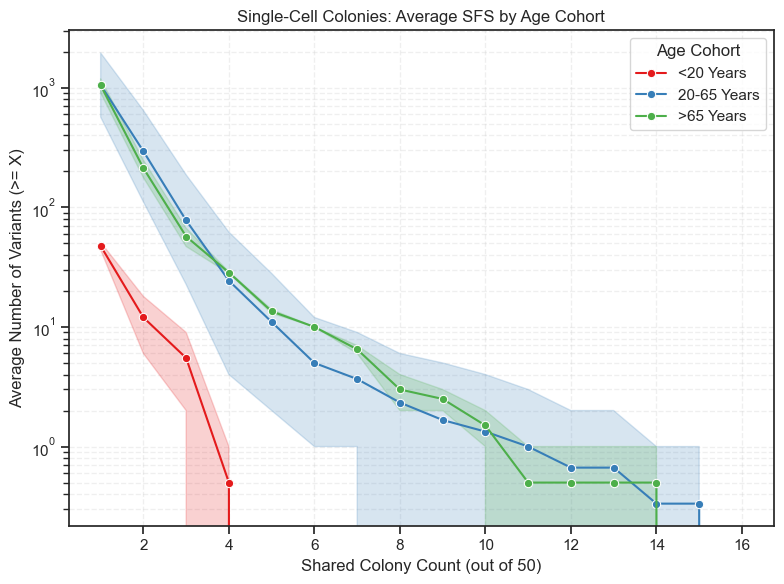

In [10]:
def plot_cohort_sfs(df, sample_col, value_col, max_val, title, xlabel):
    # 1. Calculate SFS per sample first to build a clean dataframe for seaborn
    thresholds = np.arange(1, int(max_val) + 2)
    sfs_records = []
    
    for sample_id, group in df.groupby(sample_col):
        age = group['age'].iloc[0]
        for t in thresholds:
            count = (group[value_col] >= t).sum()
            sfs_records.append({'sample': sample_id, 'age': age, 'threshold': t, 'count': count})
            
    df_sfs = pd.DataFrame(sfs_records)
    
    # 2. Bin ages into cohorts
    # Adjust these bins based on the distribution of your data!
    bins = [-1, 20, 65, 100]
    labels = ['<20 Years', '20-65 Years', '>65 Years']
    df_sfs['Age Cohort'] = pd.cut(df_sfs['age'], bins=bins, labels=labels)
    
    # 3. Plot
    plt.figure(figsize=(8, 6))
    sns.lineplot(
        data=df_sfs, 
        x='threshold', 
        y='count', 
        hue='Age Cohort', 
        palette='Set1',
        marker='o',
        errorbar=('ci', 95) # Adds 95% confidence interval shading
    )
    
    plt.yscale('log')
    plt.xlabel(xlabel)
    plt.ylabel("Average Number of Variants (>= X)")
    plt.title(title)
    plt.grid(True, which="both", ls="--", alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plot Bulk Data Cohorts
plot_cohort_sfs(
    df_bulk_norm, 'sample_id', 'N_ALT_norm', df_bulk_norm['N_ALT_norm'].max(),
    f"Bulk PBMCs: Average SFS by Age Cohort", f"Normalized Read Count (out of {TARGET_DEPTH})"
)

# Plot Single-Cell Cohorts
plot_cohort_sfs(
    df_sc_norm, 'patient_id', 'shared_norm', df_sc_norm['shared_norm'].max(),
    f"Single-Cell Colonies: Average SFS by Age Cohort", f"Shared Colony Count (out of {TARGET_COLONIES})"
)

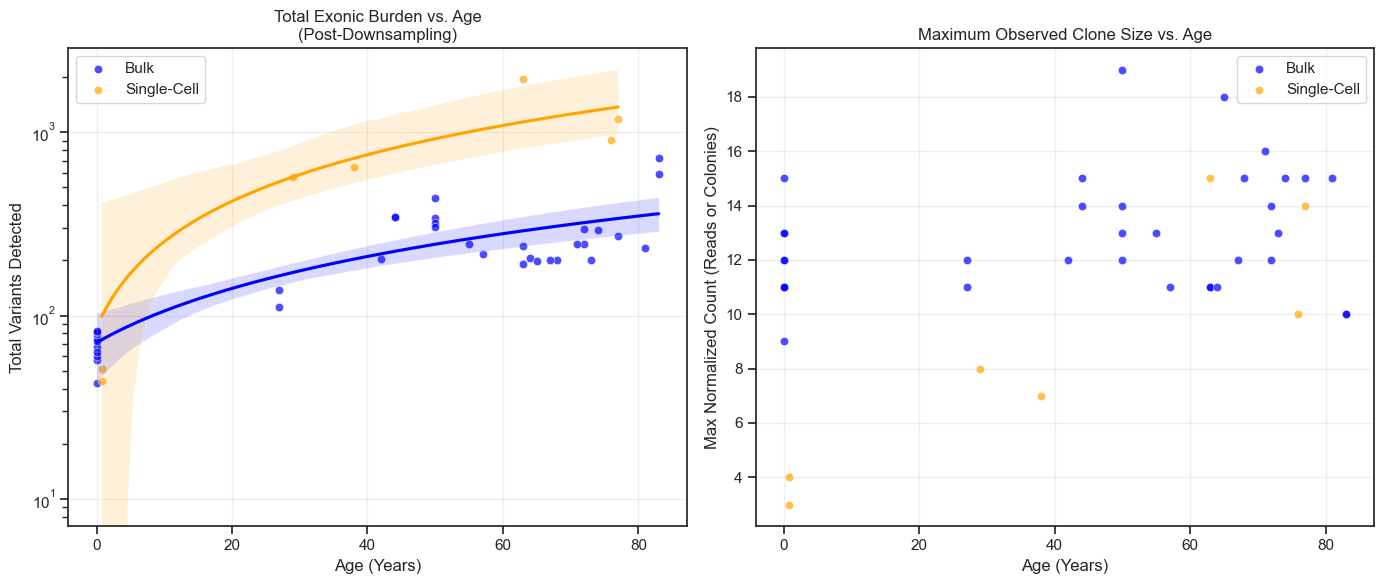

In [11]:
# 1. Extract Metrics for Bulk
bulk_metrics = df_bulk_norm.groupby('sample_id').agg(
    age=('age', 'first'),
    total_burden=('N_ALT_norm', 'size'), # Y-intercept of SFS
    max_clone_size=('N_ALT_norm', 'max') # Furthest point on X-axis of SFS
).reset_index()
bulk_metrics['dataset'] = 'Bulk PBMC'

# 2. Extract Metrics for Single-Cell
sc_metrics = df_sc_norm.groupby('patient_id').agg(
    age=('age', 'first'),
    total_burden=('shared_norm', 'size'), 
    max_clone_size=('shared_norm', 'max') 
).reset_index()
sc_metrics['dataset'] = 'Single-Cell Colony'

# 3. Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot A: Total Burden vs Age
sns.scatterplot(data=bulk_metrics, x='age', y='total_burden', color='blue', alpha=0.7, label='Bulk', ax=axes[0])
sns.scatterplot(data=sc_metrics, x='age', y='total_burden', color='orange', alpha=0.7, label='Single-Cell', ax=axes[0])

# Add trendlines (optional but helpful)
sns.regplot(data=bulk_metrics, x='age', y='total_burden', scatter=False, color='blue', ax=axes[0])
sns.regplot(data=sc_metrics, x='age', y='total_burden', scatter=False, color='orange', ax=axes[0])

axes[0].set_yscale('log')
axes[0].set_title("Total Exonic Burden vs. Age\n(Post-Downsampling)")
axes[0].set_xlabel("Age (Years)")
axes[0].set_ylabel("Total Variants Detected")
axes[0].grid(True, alpha=0.3)

# Subplot B: Maximum Clone Size vs Age
sns.scatterplot(data=bulk_metrics, x='age', y='max_clone_size', color='blue', alpha=0.7, label='Bulk', ax=axes[1])
sns.scatterplot(data=sc_metrics, x='age', y='max_clone_size', color='orange', alpha=0.7, label='Single-Cell', ax=axes[1])

axes[1].set_title("Maximum Observed Clone Size vs. Age")
axes[1].set_xlabel("Age (Years)")
axes[1].set_ylabel("Max Normalized Count (Reads or Colonies)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Filtering out C>A and G>T variants...
Bulk variants retained: 6,768 / 8,016
Single-cell variants retained: 4,890 / 5,348


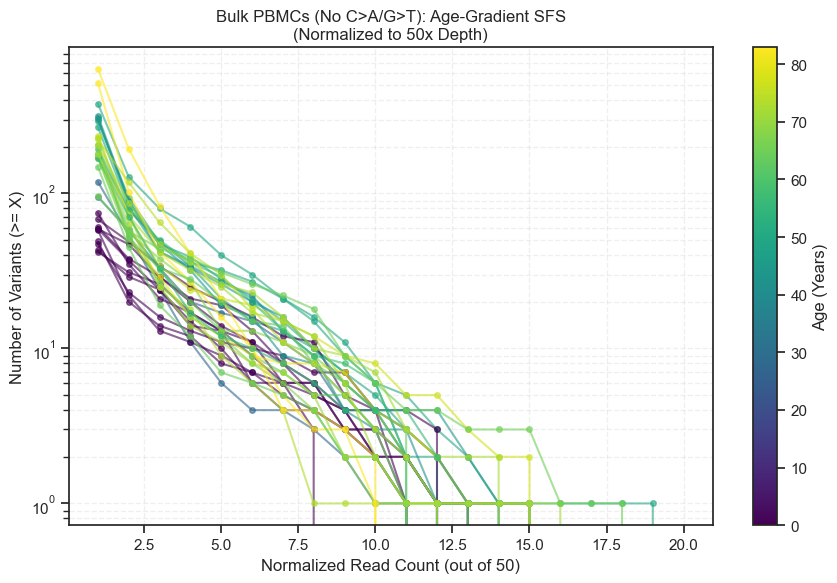

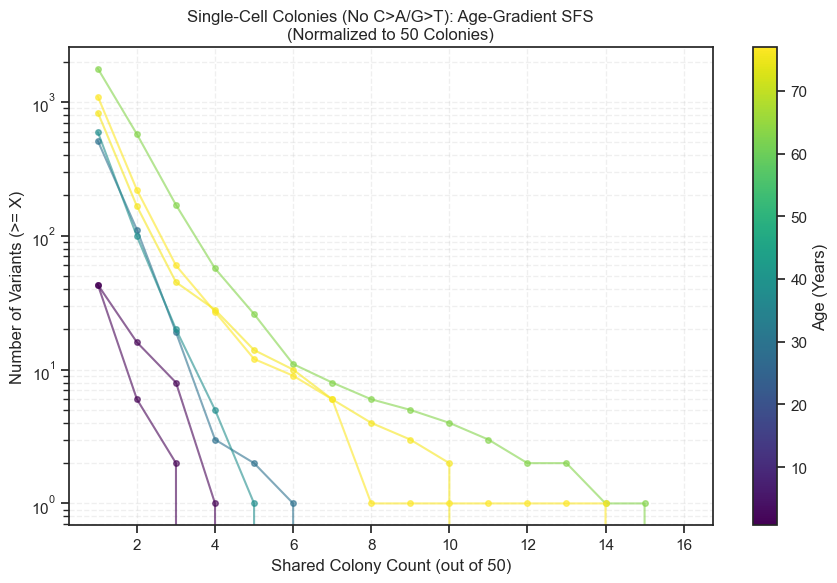

In [12]:
# 1. Helper function to filter out C>A and G>T
def remove_ca_variants(df):
    # Identify C>A and G>T mutations
    is_c_to_a = (df['REF'] == 'C') & (df['ALT'] == 'A')
    is_g_to_t = (df['REF'] == 'G') & (df['ALT'] == 'T')
    
    # Return dataframe keeping everything EXCEPT those
    return df[~(is_c_to_a | is_g_to_t)].copy()

# 2. Apply filter
print("Filtering out C>A and G>T variants...")
df_bulk_no_ca = remove_ca_variants(df_bulk_norm)
df_sc_no_ca = remove_ca_variants(df_sc_norm)

print(f"Bulk variants retained: {len(df_bulk_no_ca):,} / {len(df_bulk_norm):,}")
print(f"Single-cell variants retained: {len(df_sc_no_ca):,} / {len(df_sc_norm):,}")

# 3. Plot Bulk Data (No C>A)
plot_age_gradient_sfs(
    df=df_bulk_no_ca, 
    sample_col='sample_id', 
    value_col='N_ALT_norm', 
    max_val=df_bulk_no_ca['N_ALT_norm'].max(),
    title=f"Bulk PBMCs (No C>A/G>T): Age-Gradient SFS\n(Normalized to {TARGET_DEPTH}x Depth)",
    xlabel=f"Normalized Read Count (out of {TARGET_DEPTH})"
)

# 4. Plot Single-Cell Data (No C>A)
plot_age_gradient_sfs(
    df=df_sc_no_ca, 
    sample_col='patient_id', 
    value_col='shared_norm', 
    max_val=df_sc_no_ca['shared_norm'].max(),
    title=f"Single-Cell Colonies (No C>A/G>T): Age-Gradient SFS\n(Normalized to {TARGET_COLONIES} Colonies)",
    xlabel=f"Shared Colony Count (out of {TARGET_COLONIES})"
)